MODELLING OUR DATA

In [3]:
import pandas as pd  
import numpy as np   


In [4]:
df = pd.read_csv("/home/melody/carjacking-detection/data/merged_cleaned.csv")
print(df.shape)
print(df.columns.tolist())

(58374, 51)
['sourceimei', 'battery_voltage_value', 'hardware_attached_gps_not_present', 'unitdatetime', 'latitude', 'longitude', 'altitude', 'speed', 'heading', 'bearing', 'odometer', 'gforce_forward', 'gforce_backward', 'gforce_up', 'gforce_down', 'gforce_left', 'gforce_right', 'engine_hours', 'classification', 'condition', 'country', 'distance_suburb', 'municipality', 'postal_code', 'province', 'road', 'road_distance_m', 'rough_road', 'roadspeed', 'suburb', 'town', 'hour', 'dayofweek', 'is_stationary', 'is_odd_hour', 'suspicious', 'gforce_anomaly', 'risk_event', 'IMEI', 'Make', 'Model', 'Colour', 'Year', 'Age', 'Gender', 'month', 'is_weekend', 'is_night', 'vehicle_age', 'gforce_magnitude', 'gender_encoded']


DBSCAN - HOTSPOT CLUSTERING 
The clusters = carjacking hotspots

In [ ]:
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler

#use location data for clustering
coords = df[['latitude', 'longitude']].values

#scale it
scaler = StandardScaler()
coords_scaled = scaler.fit_transform(coords)

#DBSCAN
db = DBSCAN(eps=0.3, min_samples=5, n_jobs=-1)
df['cluster'] = db.fit_predict(coords_scaled)

#-1 means noise/outlier, everything else is a cluster
print(df['cluster'].value_counts())
print(f"Number of clusters found: {df['cluster'].nunique() - 1 }")

VISUALIZE CLUSTERS ON A MAP

In [5]:
import folium
from folium.plugins import MarkerCluster

m = folium.Map(location=[df['latitude'].mean(), 
                          df['longitude'].mean()], zoom_start=11)

# plot risk events by cluster
colors = ['red', 'blue', 'green', 'purple', 'orange', 'darkred', 'lightred']

for _, row in df[df['risk_event'] == True].iterrows():
    cluster_id = row['cluster']
    color = colors[cluster_id % len(colors)] if cluster_id != -1 else 'gray'
    
    folium.CircleMarker(
        location=[row['latitude'], row['longitude']],
        radius=5,
        color=color,
        fill=True,
        popup=f"Cluster: {cluster_id} | Hour: {row['hour']} | Speed: {row['speed']}"
    ).add_to(m)

m.save('hotspots.html')
 

KeyError: 'cluster'

In [6]:
from sklearn.cluster import DBSCAN
import numpy as np

# only cluster the 862 flagged risk events, not all 58k rows
risk_df = df[df['risk_event'] == True].copy()

print(f"Running DBSCAN on {len(risk_df)} risk events only")

coords = risk_df[['latitude', 'longitude']].values

db = DBSCAN(eps=0.05, min_samples=3, n_jobs=-1)
risk_df['cluster'] = db.fit_predict(coords)

print(risk_df['cluster'].value_counts())
print(f"Clusters found: {risk_df['cluster'].nunique() - 1}")

Running DBSCAN on 862 risk events only
cluster
1    428
0    419
2     15
Name: count, dtype: int64
Clusters found: 2


              precision    recall  f1-score   support

           0       1.00      1.00      1.00     11503
           1       1.00      0.99      0.99       172

    accuracy                           1.00     11675
   macro avg       1.00      0.99      1.00     11675
weighted avg       1.00      1.00      1.00     11675



<Axes: >

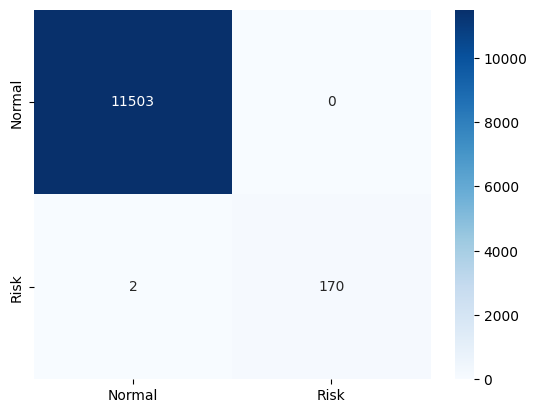

In [7]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

drop_cols = ['sourceimei', 'IMEI', 'unitdatetime', 'country',
             'province', 'municipality', 'road', 'suburb', 'town',
             'Make', 'Model', 'Colour', 'Gender', 'dayofweek',
             'suspicious', 'gforce_anomaly',
             'risk_event']

X = df.drop(columns=drop_cols)
y = df['risk_event']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

model = RandomForestClassifier(
    n_estimators=100,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Normal', 'Risk'],
            yticklabels=['Normal', 'Risk'])

In [8]:
import folium

m = folium.Map(location=[risk_df['latitude'].mean(),
                          risk_df['longitude'].mean()], zoom_start=11)

colors = ['red','blue','green','purple','orange','darkred','cadetblue']

for _, row in risk_df.iterrows():
    cid = row['cluster']
    color = colors[cid % len(colors)] if cid != -1 else 'gray'
    folium.CircleMarker(
        location=[row['latitude'], row['longitude']],
        radius=6,
        color=color,
        fill=True,
        popup=f"Cluster: {cid} | Hour: {row['hour']} | {row['suburb']}"
    ).add_to(m)

m.save('/home/melody/carjacking-detection/notebooks/hotspots.html')
 

In [9]:
print(risk_df['cluster'].value_counts())

# see which suburbs each cluster covers
print(risk_df.groupby('cluster')['suburb'].value_counts())

# see what hours each cluster is active
print(risk_df.groupby('cluster')['hour'].mean())

cluster
1    428
0    419
2     15
Name: count, dtype: int64
cluster  suburb         
0        Bramley Park       107
         Wynberg             94
         Bramley             74
         Raumarais Park      50
         Bramley North       50
                           ... 
1        Coronation Park      1
         Strubensvallei       1
2        Rivonia              8
         Buccleuch            5
         Woodmead             2
Name: count, Length: 63, dtype: int64
cluster
0     8.945107
1     9.282710
2    12.533333
Name: hour, dtype: float64


BUILDING ROBERT'S ALERT FUNCTION

In [11]:
import numpy as np
from sklearn.neighbors import BallTree

# build a lookup of hotspot centers
hotspot_centers = risk_df[risk_df['cluster'] != -1].groupby('cluster')[['latitude','longitude']].mean()
print(hotspot_centers)

def robert_alert(current_lat, current_lon, current_hour, model, df_merged):
    """
    Robert's brain — PROVIDED THAT WE ARE given current location and time,
    assess risk and alert driver.
    """
    
    # Step 1 — am I near a known hotspot cluster?
    danger_radius_km = 1.5
    alert_triggered = False
    nearest_cluster = None
    min_distance = float('inf')
    
    for cluster_id, center in hotspot_centers.iterrows():
        # haversine distance in km
        lat1, lon1 = np.radians(current_lat), np.radians(current_lon)
        lat2, lon2 = np.radians(center['latitude']), np.radians(center['longitude'])
        dlat = lat2 - lat1
        dlon = lon2 - lon1
        a = np.sin(dlat/2)**2 + np.cos(lat1)*np.cos(lat2)*np.sin(dlon/2)**2
        distance_km = 2 * 6371 * np.arcsin(np.sqrt(a))
        
        if distance_km < min_distance:
            min_distance = distance_km
            nearest_cluster = cluster_id
    
    # Step 2 — build a feature row for Random Forest
    cluster_names = {0: 'East JHB - Bramley/Wynberg', 
                     1: 'West Gauteng - Roodepoort/Krugersdorp',
                     2: 'Sandton Corridor - Rivonia/Woodmead'}
    
    is_near_hotspot = min_distance < danger_radius_km
    is_odd_hour = (current_hour >= 20) or (current_hour <= 3)
    is_night = (current_hour >= 18) or (current_hour <= 5)
    
    # Step 3 — output Robert's alert
    print("\nROBERT ALERT SYSTEM")
    
    print(f"Location: {current_lat}, {current_lon}")
    print(f"Hour: {current_hour}:00")
    print(f"Nearest hotspot: Cluster {nearest_cluster} ({cluster_names[nearest_cluster]})")
    print(f" Distance to hotspot: {min_distance:.2f} km")
    
    if is_near_hotspot:
        print(f"\n WARNING — YOU ARE {min_distance:.2f}km FROM A HIGH RISK ZONE")
        print(f"   {cluster_names[nearest_cluster]}")
        print(f"   Avoid this area if possible")
        print(f"   Stay alert, lock doors, keep moving")
    else:
        print(f"\n SAFE — Nearest hotspot is {min_distance:.2f}km away")
    
    return {
        'is_near_hotspot': is_near_hotspot,
        'nearest_cluster': nearest_cluster,
        'distance_km': min_distance,
        'cluster_name': cluster_names[nearest_cluster]
    }

          latitude  longitude
cluster                      
0       -26.116597  28.077212
1       -26.105703  27.833007
2       -26.045399  28.071886


In [14]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split

drop_cols = ['sourceimei', 'IMEI', 'unitdatetime', 'country',
             'province', 'municipality', 'road', 'suburb', 'town',
             'Make', 'Model', 'Colour', 'Gender', 'dayofweek',
             'suspicious', 'gforce_anomaly',
             'risk_event']

X = df.drop(columns=drop_cols)
y = df['risk_event']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

model = RandomForestClassifier(
    n_estimators=100,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

model.fit(X_train, y_train)
 

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [16]:
import joblib
joblib.dump(model, '/home/melody/carjacking-detection/models/robert_model.pkl')

# to reload anytime
# model = joblib.load('models/robert_model.pkl')

['/home/melody/carjacking-detection/models/robert_model.pkl']

In [17]:
# test with Sandton coordinates
robert_alert(-26.1076, 28.0567, 12, model, df)

# test with Bramley
robert_alert(-26.1225, 28.0788, 9, model, df)

# test with somewhere safe like Pretoria
robert_alert(-25.7479, 28.2293, 14, model, df)


ROBERT ALERT SYSTEM
Location: -26.1076, 28.0567
Hour: 12:00
Nearest hotspot: Cluster 0 (East JHB - Bramley/Wynberg)
 Distance to hotspot: 2.28 km

 SAFE — Nearest hotspot is 2.28km away

ROBERT ALERT SYSTEM
Location: -26.1225, 28.0788
Hour: 9:00
Nearest hotspot: Cluster 0 (East JHB - Bramley/Wynberg)
 Distance to hotspot: 0.68 km

 WARNING — YOU ARE 0.68km FROM A HIGH RISK ZONE
   East JHB - Bramley/Wynberg
   Avoid this area if possible
   Stay alert, lock doors, keep moving

ROBERT ALERT SYSTEM
Location: -25.7479, 28.2293
Hour: 14:00
Nearest hotspot: Cluster 2 (Sandton Corridor - Rivonia/Woodmead)
 Distance to hotspot: 36.64 km

 SAFE — Nearest hotspot is 36.64km away


{'is_near_hotspot': np.False_,
 'nearest_cluster': 2,
 'distance_km': np.float64(36.636701735177446),
 'cluster_name': 'Sandton Corridor - Rivonia/Woodmead'}

FINAL HOTSPOT MAP

In [19]:
import folium

m = folium.Map(location=[-26.1, 28.0], zoom_start=11)

cluster_info = {
    0: ('East JHB — Bramley/Wynberg', 'red'),
    1: ('West Gauteng — Roodepoort/Krugersdorp', 'blue'),
    2: ('Sandton Corridor — Rivonia/Woodmead', 'purple')
}

for cluster_id, (name, color) in cluster_info.items():
    center = hotspot_centers.loc[cluster_id]
    folium.Circle(
        location=[center['latitude'], center['longitude']],
        radius=1500,
        color=color,
        fill=True,
        fill_opacity=0.3,
        popup=f"⚠️ HOTSPOT: {name}"
    ).add_to(m)
    folium.Marker(
        location=[center['latitude'], center['longitude']],
        popup=name,
        icon=folium.Icon(color=color, icon='warning-sign', prefix='glyphicon')
    ).add_to(m)

m.save('/home/melody/carjacking-detection/html/robert_hotspots_final.html')
 

In [20]:
import json

hotspots = {
    0: {"name": "East JHB — Bramley/Wynberg", "lat": -26.116597, "lon": 28.077212, "color": "red"},
    1: {"name": "West Gauteng — Roodepoort/Krugersdorp", "lat": -26.105703, "lon": 27.833007, "color": "blue"},
    2: {"name": "Sandton Corridor — Rivonia/Woodmead", "lat": -26.045399, "lon": 28.071886, "color": "purple"}
}

with open('/home/melody/carjacking-detection/models/hotspots.json', 'w') as f:
    json.dump(hotspots, f)

 